In [ ]:
import pandas as pd
df = pd.read_csv('train.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [ ]:
miss = df.isnull().sum()
miss = miss[miss > 0].sort_values(ascending = False)
miss

,0
Cabin,687
Age,177
Embarked,2


In [ ]:
df_copy = df.copy()
df_copy.drop('Name', axis = 1, inplace = True)
df_copy.head()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
df_copy.drop(columns = ['Ticket', 'Cabin'], axis = 1, inplace = True)

In [ ]:
df_copy.head()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,1,0,3,male,22.0,1,0,7.2500,S
1,2,1,1,female,38.0,1,0,71.2833,C
2,3,1,3,female,26.0,0,0,7.9250,S
3,4,1,1,female,35.0,1,0,53.1000,S
4,5,0,3,male,35.0,0,0,8.0500,S


<Axes: >

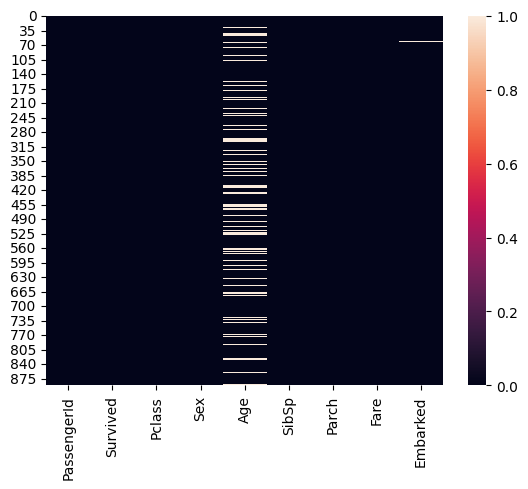

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.heatmap(df_copy.isnull())

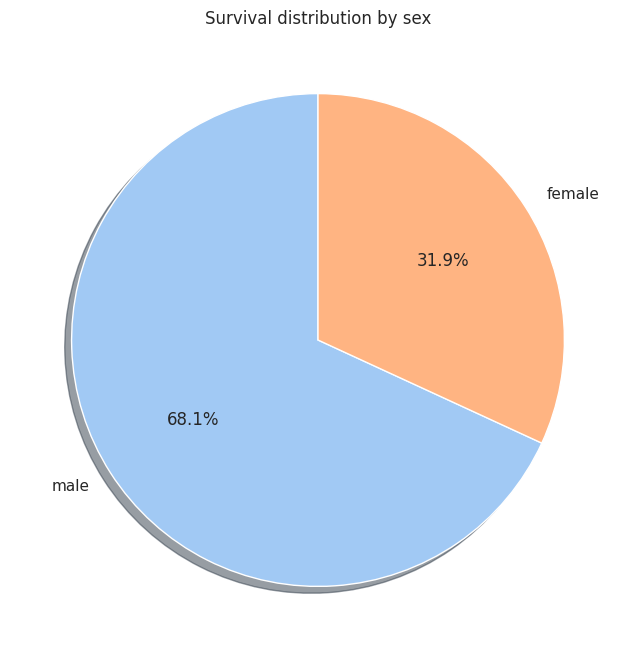

In [ ]:
sns.set_theme()
sns.set_palette('pastel')
survival = df_copy.groupby('Sex')['Survived'].sum()
counts = df_copy['Sex'].value_counts()
plt.figure(figsize = (12, 8))
plt.pie(survival, labels = counts.index, autopct='%1.1f%%', startangle = 90, shadow = True)
plt.title('Survival distribution by sex')
plt.show()

In [ ]:
df_copy['Age'].fillna(df_copy['Age'].mean(), inplace = True)

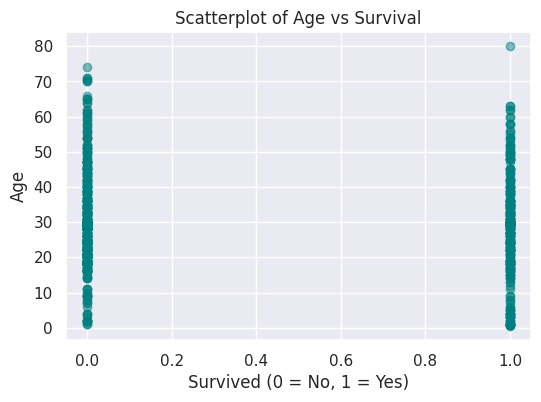

In [ ]:
plt.figure(figsize=(6,4))
plt.scatter(df_copy['Survived'], df_copy['Age'], alpha=0.5, c='teal')
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.ylabel("Age")
plt.title("Scatterplot of Age vs Survival")
plt.show()

In [ ]:
df_copy['Embarked'].value_counts()

,count
Embarked,
S,644
C,168
Q,77


In [ ]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df_copy['Sex'] = le.fit_transform(df_copy['Sex'])
df_copy['Embarked'] = le.fit_transform(df_copy['Embarked'])

In [ ]:
df_copy

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,1,0,3,1,22.000000,1,0,7.2500,2
1,2,1,1,0,38.000000,1,0,71.2833,0
2,3,1,3,0,26.000000,0,0,7.9250,2
3,4,1,1,0,35.000000,1,0,53.1000,2
4,5,0,3,1,35.000000,0,0,8.0500,2
...,...,...,...,...,...,...,...,...,...
886,887,0,2,1,27.000000,0,0,13.0000,2
887,888,1,1,0,19.000000,0,0,30.0000,2
888,889,0,3,0,29.699118,1,2,23.4500,2
889,890,1,1,1,26.000000,0,0,30.0000,0


In [ ]:
df_copy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Sex          891 non-null    int64  
 4   Age          891 non-null    float64
 5   SibSp        891 non-null    int64  
 6   Parch        891 non-null    int64  
 7   Fare         891 non-null    float64
 8   Embarked     891 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 62.8 KB


In [ ]:
from sklearn.model_selection import train_test_split, cross_val_score
import xgboost as xgb
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report

In [ ]:
df_copy['Familysize'] = df_copy['SibSp'] + df_copy['Parch'] + 1
df_copy['IsAlone'] = 0
df_copy.loc[df_copy['Familysize'] == 1, 'IsAlone'] = 1
df_copy.head()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Familysize,IsAlone
0,1,0,3,1,22.0,1,0,7.2500,2,2,0
1,2,1,1,0,38.0,1,0,71.2833,0,2,0
2,3,1,3,0,26.0,0,0,7.9250,2,1,1
3,4,1,1,0,35.0,1,0,53.1000,2,2,0
4,5,0,3,1,35.0,0,0,8.0500,2,1,1


In [ ]:
df_copy['Ischild'] = 0
df_copy.loc[df_copy['Age'] >= 18, 'Ischild'] = 0
df_copy.loc[df_copy['Age']< 18, 'Ischild'] = 1
df_copy.head()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Familysize,IsAlone,Ischild
0,1,0,3,1,22.0,1,0,7.2500,2,2,0,0
1,2,1,1,0,38.0,1,0,71.2833,0,2,0,0
2,3,1,3,0,26.0,0,0,7.9250,2,1,1,0
3,4,1,1,0,35.0,1,0,53.1000,2,2,0,0
4,5,0,3,1,35.0,0,0,8.0500,2,1,1,0


In [ ]:
x = df_copy.drop(columns = ['Ischild','Survived'], axis = 1)
y = df_copy['Survived']
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.25, random_state = 42)

In [ ]:
xgbmodel = XGBClassifier(eval_metric = 'logloss', random_state = 42)
xgbmodel.fit(x_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

In [ ]:
xgbpred = xgbmodel.predict(x_test)
print(accuracy_score(y_test, xgbpred))
print(classification_report(y_test, xgbpred))

0.8071748878923767
              precision    recall  f1-score   support

           0       0.83      0.85      0.84       134
           1       0.77      0.74      0.75        89

    accuracy                           0.81       223
   macro avg       0.80      0.80      0.80       223
weighted avg       0.81      0.81      0.81       223



In [ ]:
from lightgbm import LGBMClassifier
lgbmodel = LGBMClassifier(random_state = 42, force_row_wise = True)
lgbmodel.fit(x_train, y_train)

[LightGBM] [Info] Number of positive: 253, number of negative: 415
[LightGBM] [Info] Total Bins 427
[LightGBM] [Info] Number of data points in the train set: 668, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.378743 -> initscore=-0.494889
[LightGBM] [Info] Start training from score -0.494889
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


LGBMClassifier(force_row_wise=True, random_state=42)

In [ ]:
lgbpred = lgbmodel.predict(x_test)
print(accuracy_score(y_test, lgbpred))
print(classification_report(y_test, lgbpred))

0.820627802690583
              precision    recall  f1-score   support

           0       0.84      0.87      0.85       134
           1       0.80      0.74      0.77        89

    accuracy                           0.82       223
   macro avg       0.82      0.81      0.81       223
weighted avg       0.82      0.82      0.82       223



In [ ]:
from sklearn.linear_model import LogisticRegression
lrmodel = LogisticRegression(random_state = 42, max_iter = 1500)
lrmodel.fit(x_train, y_train)

LogisticRegression(max_iter=1500, random_state=42)

In [ ]:
lrpred = lrmodel.predict(x_test)
print(accuracy_score(y_test, lrpred))
print(classification_report(y_test, lrpred))

0.7982062780269058
              precision    recall  f1-score   support

           0       0.82      0.85      0.84       134
           1       0.76      0.72      0.74        89

    accuracy                           0.80       223
   macro avg       0.79      0.78      0.79       223
weighted avg       0.80      0.80      0.80       223



In [ ]:
from sklearn.ensemble import RandomForestClassifier
rfmodel = RandomForestClassifier(random_state = 42)
rfmodel.fit(x_train, y_train)

RandomForestClassifier(random_state=42)

In [ ]:
rfpred = rfmodel.predict(x_test)
print(accuracy_score(y_test, rfpred))
print(classification_report(y_test, rfpred))

0.8161434977578476
              precision    recall  f1-score   support

           0       0.84      0.86      0.85       134
           1       0.78      0.75      0.77        89

    accuracy                           0.82       223
   macro avg       0.81      0.81      0.81       223
weighted avg       0.82      0.82      0.82       223

